In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [4]:
# Load data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))
OE_Activity_prepped = pd.read_parquet(Path("../data/processed/oe_activity_prepped.parquet"))
OE_joined = pd.read_parquet(Path("../data/processed/oe_joined.parquet"))    
product_pick_times = pd.read_csv(Path("../data/processed/product_pick_times.csv"))

# Rename Travel_Distance column to Distance for df OE_detailed
OE_detailed = OE_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [5]:
display(OE_detailed.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0


In [6]:
# Compute for how many productID we have a row in product_pick_times and percentage of total products
num_products_with_pick_time = product_pick_times.shape[0]
total_products = OE_Activity_prepped["ProductID"].nunique()
percentage_products_with_pick_time = (num_products_with_pick_time / total_products) * 100 if total_products > 0 else 0
print(f"Number of ProductIDs with computed pick times: {num_products_with_pick_time}")
print(f"Percentage of ProductIDs with computed pick times: {percentage_products_with_pick_time:.2f}%")

# Compute for how many productID we have n_pairs>1 and percentage of total products
num_products_with_multiple_pairs = (product_pick_times["n_pairs"] > 1).sum()
print(f"Number of ProductIDs with more than 1 pair: {num_products_with_multiple_pairs}")
percentage_products_with_multiple_pairs = (num_products_with_multiple_pairs / total_products) * 100 if total_products > 0 else 0
print(f"Percentage of ProductIDs with more than 1 pair: {percentage_products_with_multiple_pairs:.2f}%")

Number of ProductIDs with computed pick times: 2195
Percentage of ProductIDs with computed pick times: 28.54%
Number of ProductIDs with more than 1 pair: 1429
Percentage of ProductIDs with more than 1 pair: 18.58%


In [7]:
# Percentage of productIDs with avg_pick_time_sec < 1s, < 5s, and > 10s
num_products_fast_pick = (product_pick_times["avg_pick_time_sec"] < 1).sum()
num_products_moderate_pick = ((product_pick_times["avg_pick_time_sec"] >= 1) & (product_pick_times["avg_pick_time_sec"] < 10)).sum()
num_products_slow_pick = (product_pick_times["avg_pick_time_sec"] > 10).sum()
print(f"Number of ProductIDs with avg_pick_time_sec < 1s: {num_products_fast_pick} ({(num_products_fast_pick / num_products_with_pick_time) * 100:.2f}%)")
print(f"Number of ProductIDs with 1s <= avg_pick_time_sec < 10s: {num_products_moderate_pick} ({(num_products_moderate_pick / num_products_with_pick_time) * 100:.2f}%)")
print(f"Number of ProductIDs with avg_pick_time_sec > 10s: {num_products_slow_pick} ({(num_products_slow_pick / num_products_with_pick_time) * 100:.2f}%)")

Number of ProductIDs with avg_pick_time_sec < 1s: 919 (41.87%)
Number of ProductIDs with 1s <= avg_pick_time_sec < 10s: 668 (30.43%)
Number of ProductIDs with avg_pick_time_sec > 10s: 608 (27.70%)


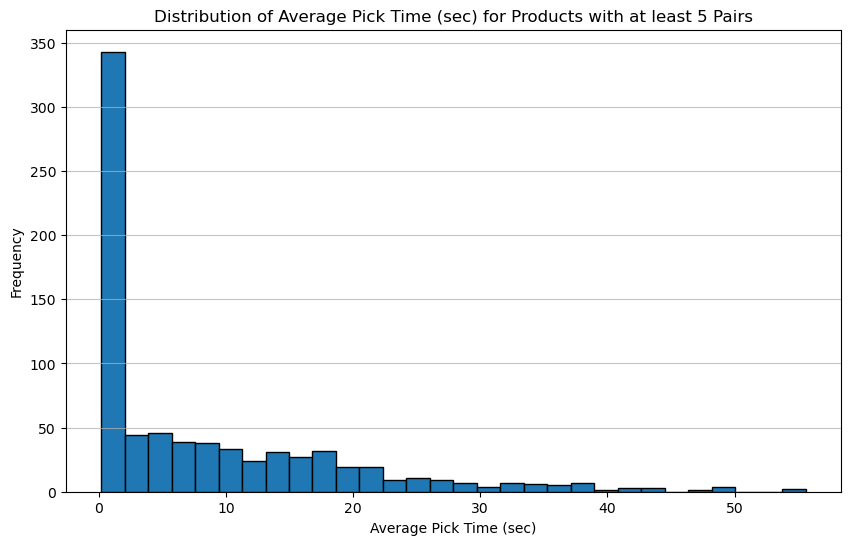

In [8]:
# PLot distribution of avg_pick_time_sec for products in product_pick_times with at least 5 pairs
plt.figure(figsize=(10, 6))
subset = product_pick_times[(product_pick_times["n_pairs"] >= 5) & 
                            (product_pick_times["avg_pick_time_sec"] > 0) & 
                            (product_pick_times["avg_pick_time_sec"] < 60)]
plt.hist(subset["avg_pick_time_sec"].dropna(), bins=30, edgecolor="k")
plt.title("Distribution of Average Pick Time (sec) for Products with at least 5 Pairs")
plt.xlabel("Average Pick Time (sec)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

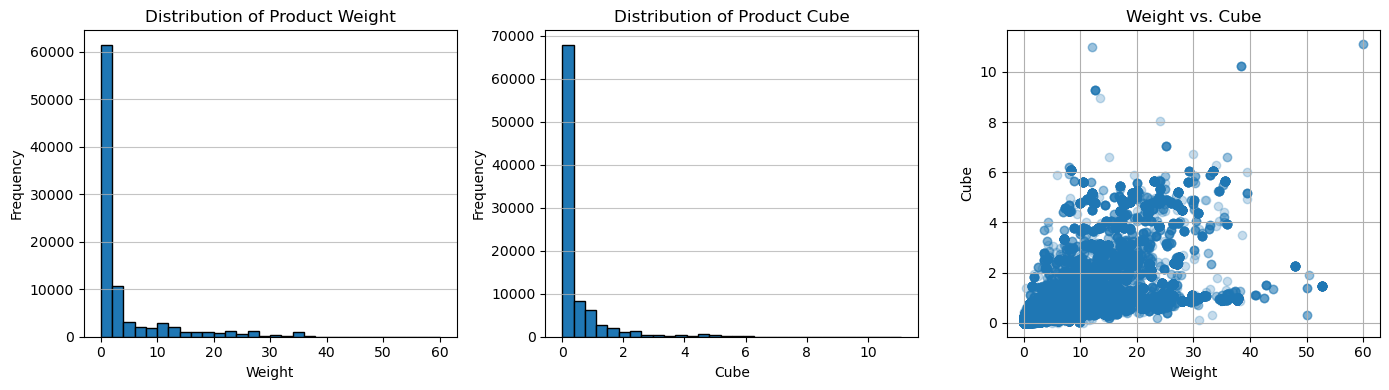

In [9]:
# Filter so weight and cude are not null or 0
filtered_OE_joined = OE_joined[
    (OE_joined["Weight"].notna()) & (OE_joined["Weight"] > 0) &
    (OE_joined["Cube"].notna()) & (OE_joined["Cube"] > 0)
].copy()
# Plot distribution of weight and cube side by side in OE_joined
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(filtered_OE_joined["Weight"].dropna(), bins=30, edgecolor="k")
plt.title("Distribution of Product Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 3, 2)
plt.hist(filtered_OE_joined["Cube"].dropna(), bins=30, edgecolor="k")
plt.title("Distribution of Product Cube")
plt.xlabel("Cube")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 3, 3)
plt.scatter(filtered_OE_joined["Weight"], filtered_OE_joined["Cube"], alpha=0.25)
plt.title("Weight vs. Cube")
plt.xlabel("Weight")
plt.ylabel("Cube")
plt.grid()
plt.tight_layout()
plt.show()

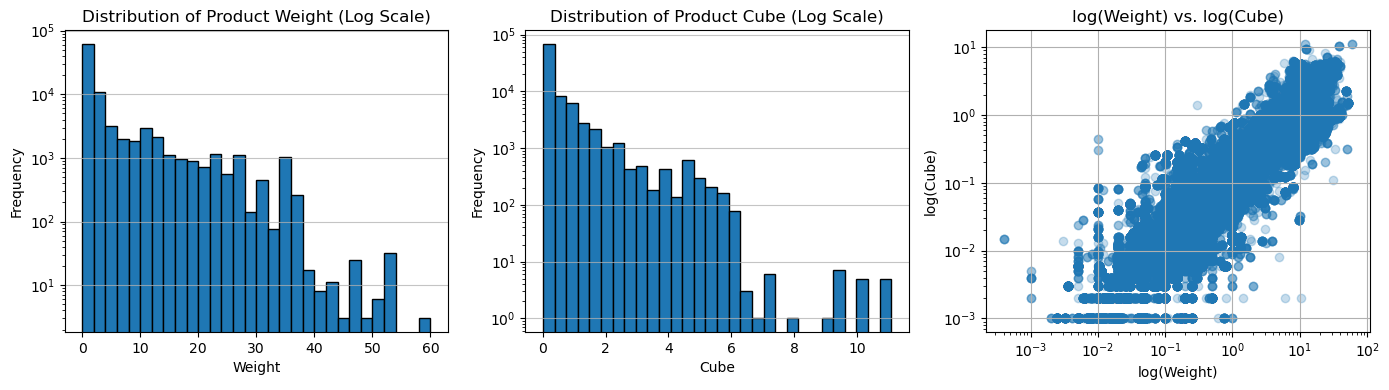

In [10]:
# Same plots oas in the rpevious chunk, but all on log scale
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(filtered_OE_joined["Weight"].dropna(), bins=30, edgecolor="k")
plt.title("Distribution of Product Weight (Log Scale)")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.yscale("log")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 3, 2)
plt.hist(filtered_OE_joined["Cube"].dropna(), bins=30, edgecolor="k")
plt.title("Distribution of Product Cube (Log Scale)")
plt.xlabel("Cube")
plt.ylabel("Frequency") 
plt.yscale("log")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 3, 3)
plt.scatter(filtered_OE_joined["Weight"], filtered_OE_joined["Cube"], alpha=0.25)
plt.title("log(Weight) vs. log(Cube)")
plt.xlabel("log(Weight)")
plt.ylabel("log(Cube)")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
# Compute correlation between weight and cube in filtered_OE_joined, normal scale and on log scale
correlation_normal = filtered_OE_joined[["Weight", "Cube"]].corr().loc["Weight", "Cube"]
correlation_log = np.log(filtered_OE_joined[["Weight", "Cube"]]).corr().loc["Weight", "Cube"]
print(f"Correlation between Weight and Cube (Normal Scale): {correlation_normal:.4f}")
print(f"Correlation between Weight and Cube (Log Scale): {correlation_log:.4f}")

Correlation between Weight and Cube (Normal Scale): 0.6570
Correlation between Weight and Cube (Log Scale): 0.8923


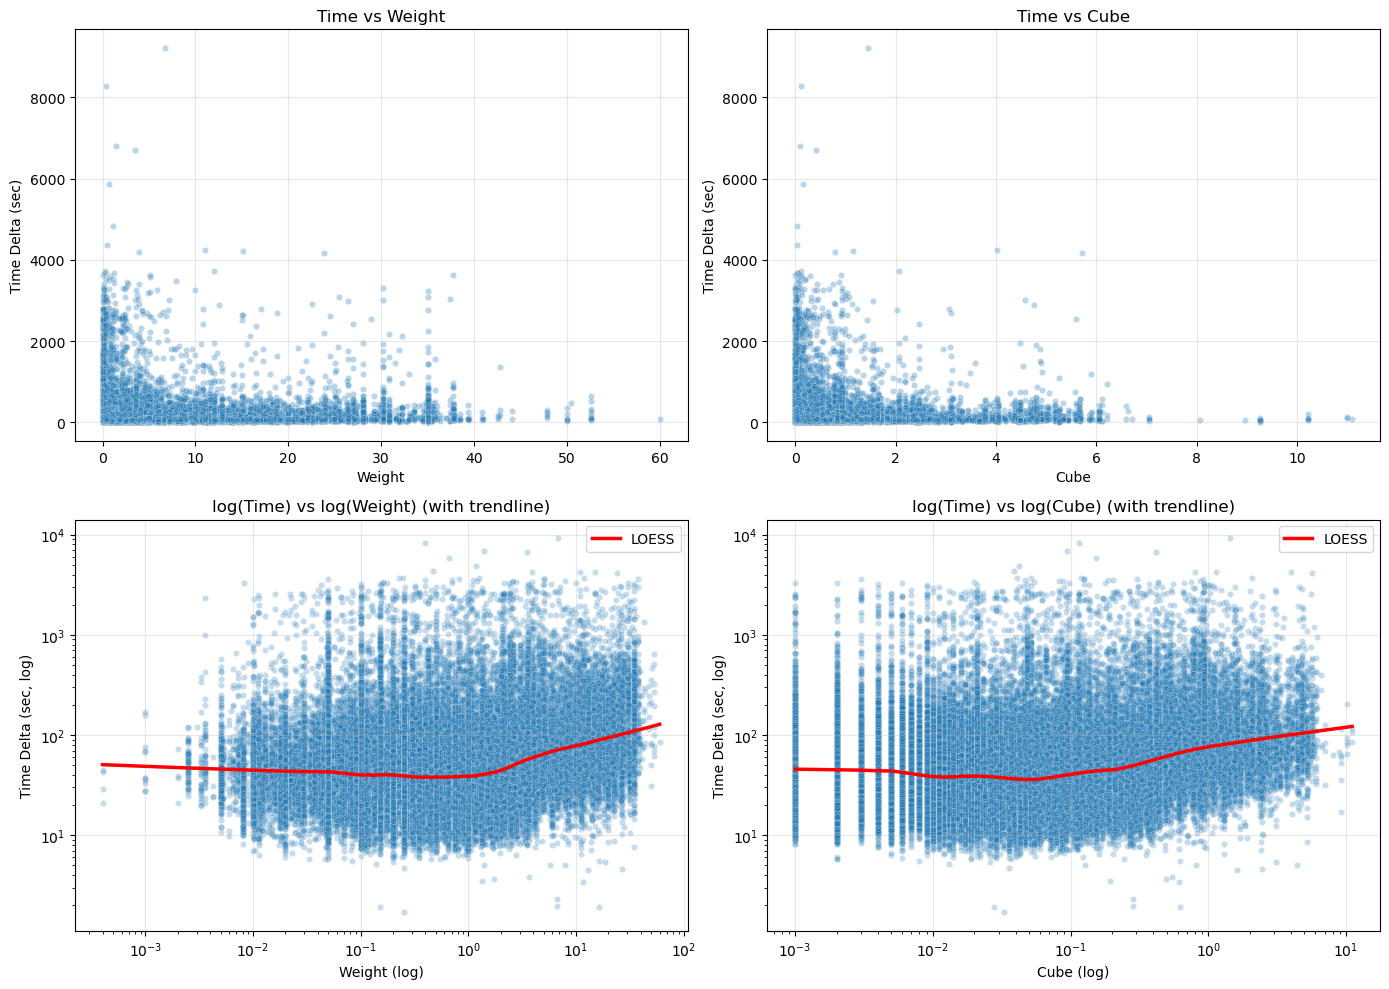

In [12]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plot_df = OE_joined[
    (OE_joined["LocationID"] != OE_joined["Prev_LocationID"]) &
    (OE_joined["Time_Delta_sec"] > 0) &
    OE_joined["Weight"].notna() &
    OE_joined["Cube"].notna()
].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------- Linear scales --------

sns.scatterplot(
    data=plot_df,
    x="Weight",
    y="Time_Delta_sec",
    alpha=0.3,
    s=20,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Time vs Weight")
axes[0, 0].set_xlabel("Weight")
axes[0, 0].set_ylabel("Time Delta (sec)")

sns.scatterplot(
    data=plot_df,
    x="Cube",
    y="Time_Delta_sec",
    alpha=0.3,
    s=20,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Time vs Cube")
axes[0, 1].set_xlabel("Cube")
axes[0, 1].set_ylabel("Time Delta (sec)")

# -------- Log–Log scales with LOESS --------

log_df = plot_df[
    (plot_df["Weight"] > 0) &
    (plot_df["Cube"] > 0)
].copy()

# --- Weight log-log plot ---
sns.scatterplot(
    data=log_df,
    x="Weight",
    y="Time_Delta_sec",
    alpha=0.25,
    s=20,
    ax=axes[1, 0]
)

# LOWESS in log-log space
x = log_df["Weight"].values
y = log_df["Time_Delta_sec"].values

smoothed = lowess(np.log(y), np.log(x), frac=0.25)
xs = np.exp(smoothed[:, 0])
ys = np.exp(smoothed[:, 1])

axes[1, 0].plot(xs, ys, color="red", linewidth=2.5, label="LOESS")

axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("log(Time) vs log(Weight) (with trendline)")
axes[1, 0].set_xlabel("Weight (log)")
axes[1, 0].set_ylabel("Time Delta (sec, log)")
axes[1, 0].legend()

# --- Cube log-log plot ---
sns.scatterplot(
    data=log_df,
    x="Cube",
    y="Time_Delta_sec",
    alpha=0.25,
    s=20,
    ax=axes[1, 1]
)

x2 = log_df["Cube"].values
y2 = log_df["Time_Delta_sec"].values

smoothed2 = lowess(np.log(y2), np.log(x2), frac=0.25)
xs2 = np.exp(smoothed2[:, 0])
ys2 = np.exp(smoothed2[:, 1])

axes[1, 1].plot(xs2, ys2, color="red", linewidth=2.5, label="LOESS")

axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("log(Time) vs log(Cube) (with trendline)")
axes[1, 1].set_xlabel("Cube (log)")
axes[1, 1].set_ylabel("Time Delta (sec, log)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

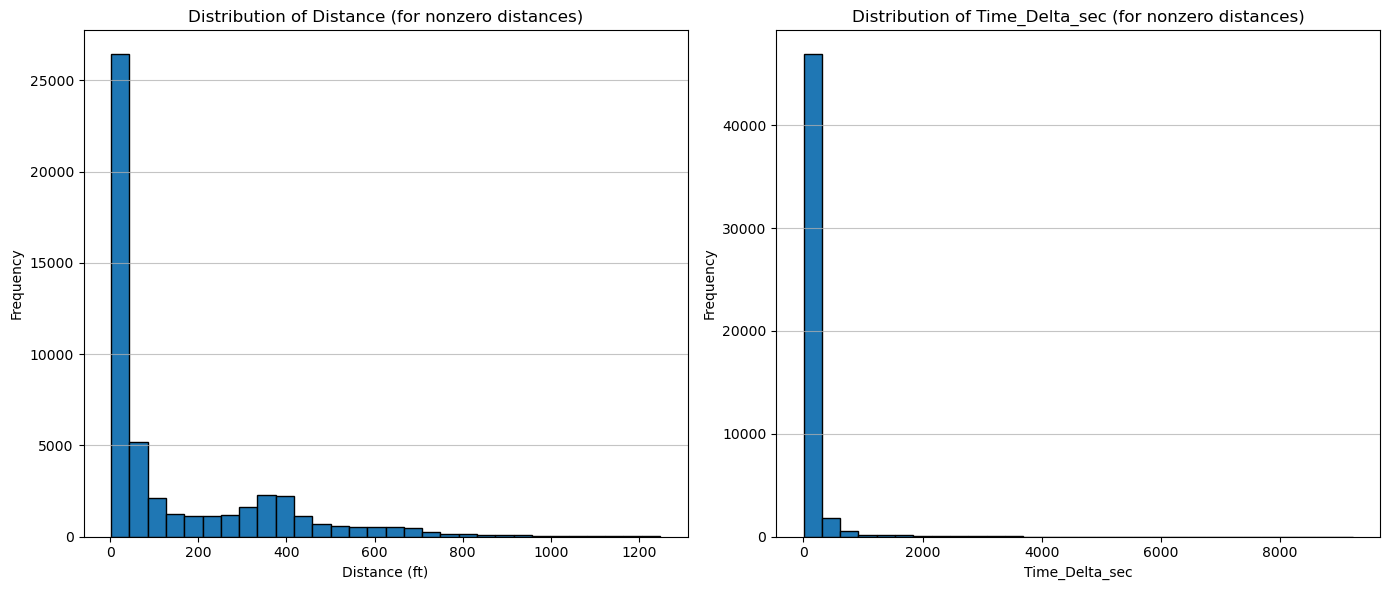

In [21]:
# Plot distributions of Distance and Time_Delta_sec side by side in OE_detailed
# For rows with Distance != 0 only 
subset = OE_detailed[(OE_detailed["Distance"].notna()) & (OE_detailed["Distance"] != 0) & (OE_detailed["Time_Delta_sec"].notna())]
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(subset["Distance"], bins=30, edgecolor="k")
plt.title("Distribution of Distance (for nonzero distances)")
plt.xlabel("Distance (ft)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 2, 2)
plt.hist(subset["Time_Delta_sec"], bins=30, edgecolor="k")
plt.title("Distribution of Time_Delta_sec (for nonzero distances)")
plt.xlabel("Time_Delta_sec")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

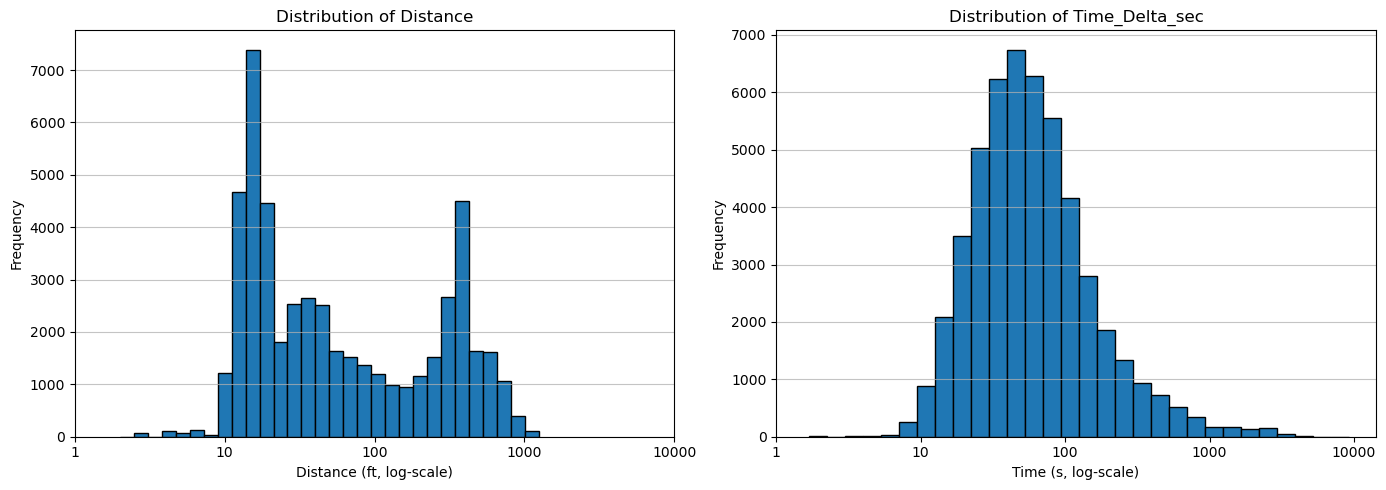

In [32]:
# Filter data
subset = OE_detailed[
    (OE_detailed["Distance"].notna()) &
    (OE_detailed["Distance"] != 0) &
    (OE_detailed["Time_Delta_sec"].notna()) &
    (OE_detailed["Time_Delta_sec"] > 0)
]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---- Distance histogram (log values plotted) ----
log_dist = np.log(subset["Distance"])
ax[0].hist(log_dist, bins=30, edgecolor="k")
ax[0].set_title("Distribution of Distance")
ax[0].set_xlabel("Distance (ft, log-scale)")
ax[0].set_ylabel("Frequency")
ax[0].grid(axis="y", alpha=0.75)

ticks = np.log([1, 10, 100, 1000, 10000])
ax[0].set_xticks(ticks)
ax[0].set_xticklabels([1, 10, 100, 1000, 10000])

# ---- Time histogram ----
log_time = np.log(subset["Time_Delta_sec"])
ax[1].hist(log_time, bins=30, edgecolor="k")
ax[1].set_title("Distribution of Time_Delta_sec")
ax[1].set_xlabel("Time (s, log-scale)")
ax[1].set_ylabel("Frequency")
ax[1].grid(axis="y", alpha=0.75)

ticks = np.log([1, 10, 100, 1000, 10000])
ax[1].set_xticks(ticks)
ax[1].set_xticklabels([1, 10, 100, 1000, 10000])

plt.tight_layout()
plt.show()

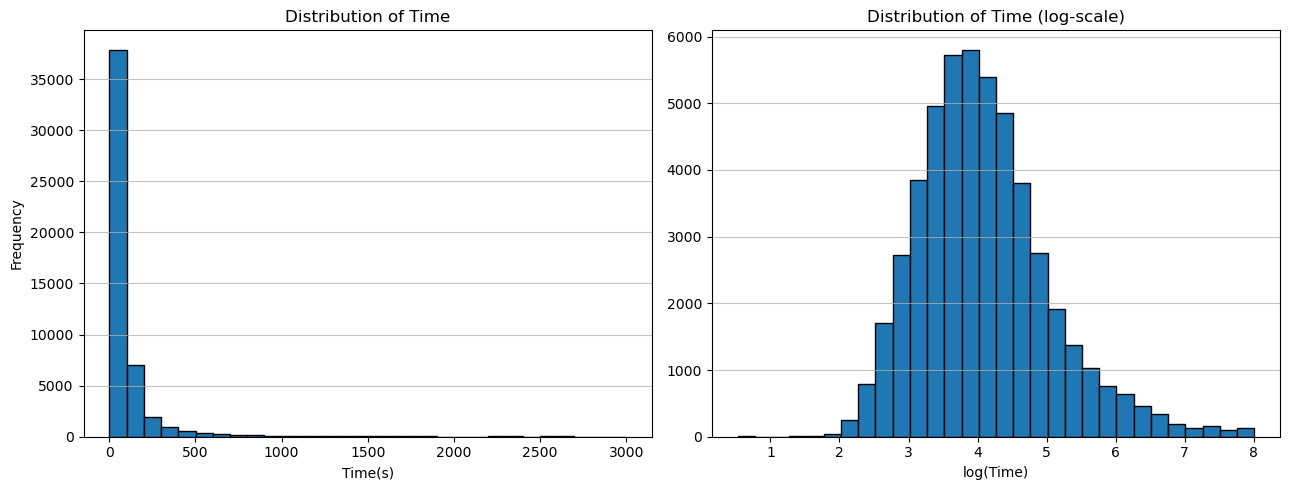

In [15]:
subset = OE_detailed[(OE_detailed["Distance"].notna()) & (OE_detailed["Distance"] != 0) & (OE_detailed["Time_Delta_sec"].notna()) & (OE_detailed["Time_Delta_sec"] > 0)& (OE_detailed["Time_Delta_sec"] < 3000)]
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plt.hist(subset["Time_Delta_sec"], bins=30, edgecolor="k")
plt.title("Distribution of Time")
plt.xlabel("Time(s)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.subplot(1, 2, 2)
plt.hist(np.log(subset["Time_Delta_sec"]), bins=30, edgecolor="k")
plt.title("Distribution of Time (log-scale)")
plt.xlabel("log(Time)")
plt.ylabel("")
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

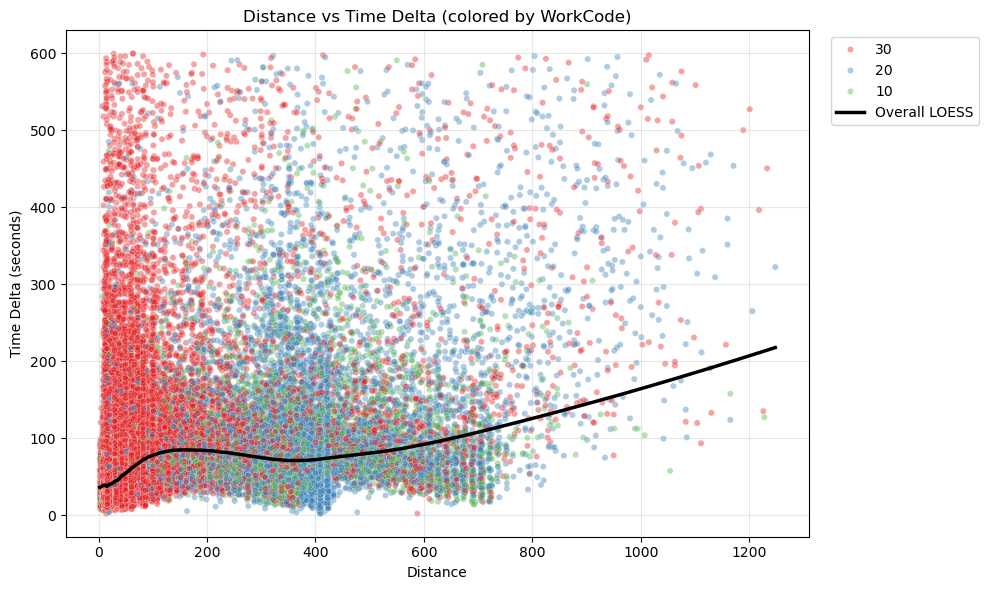

In [16]:
# In OE_detailed, plot scatter of Distance vs Time_Delta_sec colored by WorkCode
# Filter out rows with distance == 0
# Add a LOESS line or moving average line to show overall trend
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Prepare filtered dataset
plot_df = OE_detailed[
    (OE_detailed["Distance"] > 0) &
    (OE_detailed["Time_Delta_sec"] > 0) &
    (OE_detailed["Time_Delta_sec"] < 600)   # optional window
].copy()

plt.figure(figsize=(10, 6))

# Scatter colored by WorkCode
sns.scatterplot(
    data=plot_df,
    x="Distance",
    y="Time_Delta_sec",
    hue="WorkCode",
    alpha=0.4,
    s=20,
    palette="Set1"
)

x = plot_df["Distance"].values
y = plot_df["Time_Delta_sec"].values
# Compute LOWESS smooth
smoothed = lowess(y, x, frac=0.25)   # frac controls smoothness
xs, ys = smoothed[:, 0], smoothed[:, 1]

plt.plot(xs, ys, color="black", linewidth=2.5, label="Overall LOESS")
plt.title("Distance vs Time Delta (colored by WorkCode)")
plt.xlabel("Distance")
plt.ylabel("Time Delta (seconds)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

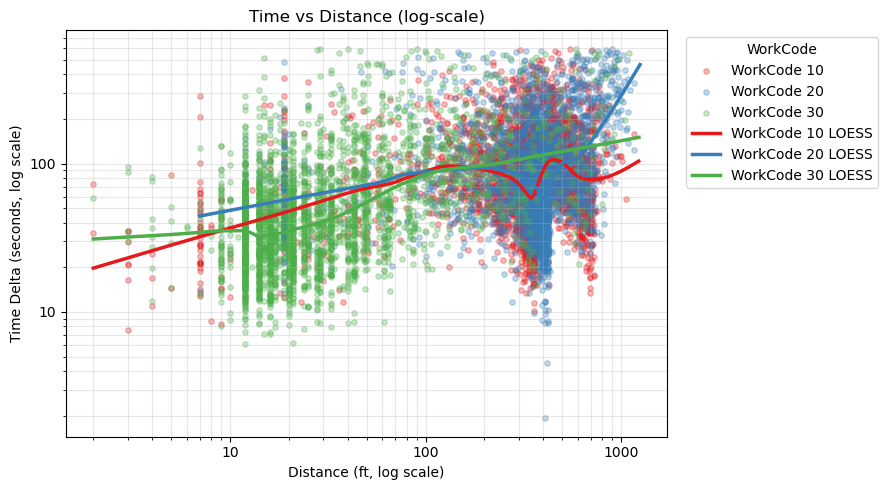

In [22]:
plot_df["WorkCode"] = plot_df["WorkCode"].astype(str)

plt.figure(figsize=(9, 5))

# Distinct palette
workcodes = sorted(plot_df["WorkCode"].unique())
palette = sns.color_palette("Set1", n_colors=len(workcodes))
color_map = dict(zip(workcodes, palette))

# ---- Scatter (subsampled for clarity) ----
for wc in workcodes:
    sub = plot_df[plot_df["WorkCode"] == wc]
    
    if len(sub) > 3000:
        sub = sub.sample(n=3000, random_state=42)

    plt.scatter(
        sub["Distance"],
        sub["Time_Delta_sec"],
        alpha=0.3,
        s=15,
        color=color_map[wc],
        label=f"WorkCode {wc}"
    )

# ---- LOESS per WorkCode ----
for wc in workcodes:
    sub = plot_df[plot_df["WorkCode"] == wc]

    # Need enough points for smoothing
    if len(sub) < 50:
        continue

    x = sub["Distance"].values
    y = sub["Time_Delta_sec"].values

    # LOWESS in log-log space
    smoothed = lowess(np.log(y), np.log(x), frac=0.3)

    xs = np.exp(smoothed[:, 0])
    ys = np.exp(smoothed[:, 1])

    plt.plot(xs, ys,
             color=color_map[wc],
             linewidth=2.5,
             label=f"WorkCode {wc} LOESS")

import matplotlib.ticker as mticker

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

# Major ticks as plain numbers
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Disable scientific notation
ax.ticklabel_format(style="plain", axis="both")

# Optional: nicer tick positions
ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))

plt.title("Time vs Distance (log-scale)")
plt.xlabel("Distance (ft, log scale)")
plt.ylabel("Time Delta (seconds, log scale)")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="WorkCode")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

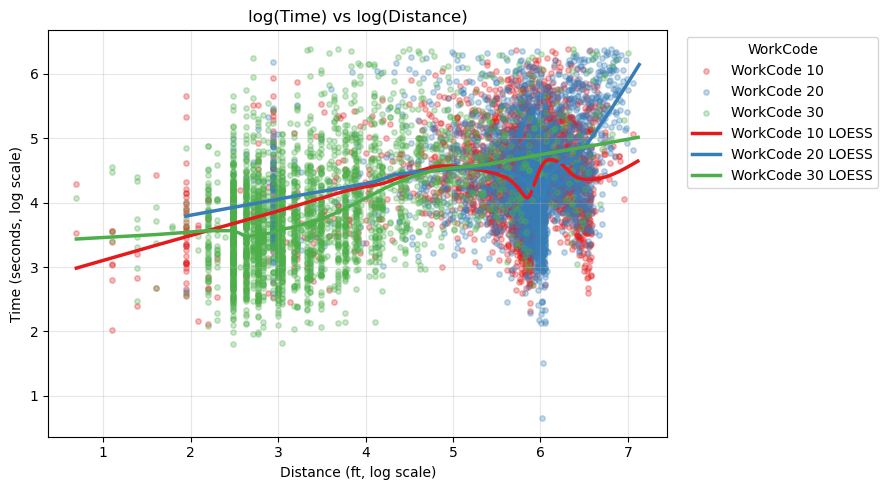

In [24]:
plot_df["WorkCode"] = plot_df["WorkCode"].astype(str)

plt.figure(figsize=(9, 5))

# Distinct palette
workcodes = sorted(plot_df["WorkCode"].unique())
palette = sns.color_palette("Set1", n_colors=len(workcodes))
color_map = dict(zip(workcodes, palette))

# ---- Scatter (subsampled for clarity) ----
for wc in workcodes:
    sub = plot_df[plot_df["WorkCode"] == wc]

    if len(sub) > 3000:
        sub = sub.sample(n=3000, random_state=42)

    plt.scatter(
        np.log(sub["Distance"]),
        np.log(sub["Time_Delta_sec"]),
        alpha=0.3,
        s=15,
        color=color_map[wc],
        label=f"WorkCode {wc}"
    )

# ---- LOESS per WorkCode (already log-log) ----
for wc in workcodes:
    sub = plot_df[plot_df["WorkCode"] == wc]

    if len(sub) < 50:
        continue

    x = np.log(sub["Distance"].values)
    y = np.log(sub["Time_Delta_sec"].values)

    smoothed = lowess(y, x, frac=0.3)

    plt.plot(
        smoothed[:, 0],
        smoothed[:, 1],
        color=color_map[wc],
        linewidth=2.5,
        label=f"WorkCode {wc} LOESS"
    )

# ---- Labels ----
plt.title("log(Time) vs log(Distance)")
plt.xlabel("Distance (ft, log scale)")
plt.ylabel("Time (seconds, log scale)")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="WorkCode")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
df = OE_joined.copy()
df = df.sort_values(["UserID", "Timestamp"]).reset_index(drop=True)

# Filter: consecutive tasks where (Aisle,Bay) same as previous, Level differs
mask = (
    df["Prev_Aisle"].notna() & df["Prev_Bay"].notna() &
    df["Aisle"].notna() & df["Bay"].notna() &
    (df["Aisle"] == df["Prev_Aisle"]) &
    (df["Bay"] == df["Prev_Bay"]) &
    df["Level"].notna() & df["Prev_Level"].notna() &
    (df["LocationID"] != df["Prev_LocationID"])
)

level_study = df.loc[mask].copy()

# Signed level delta (current - previous)
level_study["Level_Delta"] = (level_study["Level"] - level_study["Prev_Level"]).astype("Int64")

# Keep useful columns (Time_Delta_sec already exists; no recompute)
level_study = level_study[[
    "UserID", "Timestamp", "Prev_Timestamp",
    "Aisle", "Bay", "Prev_Aisle", "Prev_Bay",
    "Level", "Prev_Level", "Level_Delta",
    "Time_Delta_sec",
    "LocationID", "Prev_LocationID",
    "ProductID", "WorkCode"
]]

level_study.head()

,UserID,Timestamp,Prev_Timestamp,Aisle,Bay,Prev_Aisle,Prev_Bay,Level,Prev_Level,Level_Delta,Time_Delta_sec,LocationID,Prev_LocationID,ProductID,WorkCode
3,143,2025-09-08 12:16:30.470,2025-09-08 12:15:46.650,40,18,40,18,2,2,0,43.820,10743,422,44547,30
13,143,2025-09-08 12:25:34.360,2025-09-08 12:24:58.590,40,18,40,18,2,1,1,35.770,422,3966,460,30
16,143,2025-09-08 12:26:51.750,2025-09-08 12:26:28.270,40,14,40,14,2,6,-4,23.480,157913,18911,40501,30
19,143,2025-09-08 12:29:02.820,2025-09-08 12:27:54.287,40,13,40,13,4,6,-2,68.533,1178,12708,661,30
29,143,2025-09-08 12:35:38.960,2025-09-08 12:34:41.337,40,18,40,18,2,2,0,57.623,422,17011,460,30


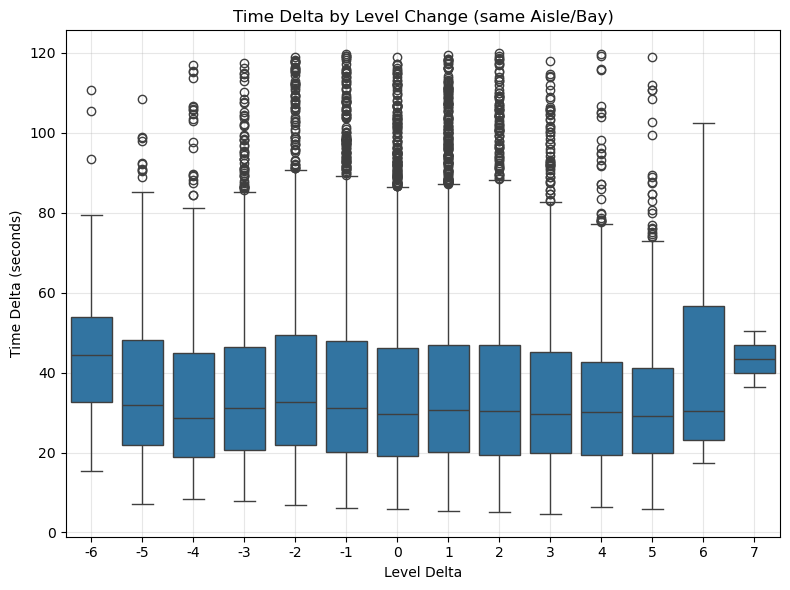

In [19]:
# Plot level delta vs time delta boxplot, for time delta less than 120s
plt.figure(figsize=(8, 6))
sns.boxplot(data=level_study[level_study["Time_Delta_sec"] < 120], x="Level_Delta", y="Time_Delta_sec")
plt.title("Time Delta by Level Change (same Aisle/Bay)")
plt.xlabel("Level Delta")
plt.ylabel("Time Delta (seconds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()